# Visualisation time series
Entrée à modifier dans la variable FILE de la première cellule

Visualisation de l'évolution des données de consommation d'énergie dans le temps

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Racine du projet — 2 niveaux au-dessus de ce notebook
# notebooks/03_visualisation/ -> notebooks/ -> FlexiMax/
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'
FILE = "100276-0.parquet"
import traceback

try:
    df = pd.read_parquet(DATA_RAW / FILE)
except Exception:
    traceback.print_exc()

print('Racine projet :', ROOT)
df = pd.read_parquet(DATA_RAW / FILE )
df_metadata = pd.read_parquet(DATA_PROCESSED / 'metadata_features.parquet')

Racine projet : C:\Users\eassoumou1\FlexiMax


In [3]:

print("="*60)
print("Dimensions du dataset")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("Liste des colonnes")
print("="*60)
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

print("\n" + "="*60)
print("Types des variables")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("Nombre de valeurs manquantes")
print("="*60)
print(df.isna().sum())

print("\n" + "="*60)
print("Aperçu des données")
print("="*60)
print(df.head())
print ("\n" + "="*60 + "\n")


Dimensions du dataset
(35040, 192)

Liste des colonnes
  1. bldg_id
  2. timestamp
  3. in.sqft
  4. out.electricity.ceiling_fan.energy_consumption..kwh
  5. out.electricity.clothes_dryer.energy_consumption..kwh
  6. out.electricity.clothes_washer.energy_consumption..kwh
  7. out.electricity.cooling.energy_consumption..kwh
  8. out.electricity.cooling_fans_pumps.energy_consumption..kwh
  9. out.electricity.dishwasher.energy_consumption..kwh
 10. out.electricity.ev_charging.energy_consumption..kwh
 11. out.electricity.freezer.energy_consumption..kwh
 12. out.electricity.heating.energy_consumption..kwh
 13. out.electricity.heating_fans_pumps.energy_consumption..kwh
 14. out.electricity.heating_hp_bkup.energy_consumption..kwh
 15. out.electricity.heating_hp_bkup_fa.energy_consumption..kwh
 16. out.electricity.hot_water.energy_consumption..kwh
 17. out.electricity.hot_water_solar_th.energy_consumption..kwh
 18. out.electricity.lighting_exterior.energy_consumption..kwh
 19. out.electricity.

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
bldg_id,35040.0,100276.0,100276.0,100276.0,100276.0,100276.0,100276.0,0.0
timestamp,35040,2018-07-02 12:07:30,2018-01-01 00:15:00,2018-04-02 06:11:15,2018-07-02 12:07:30,2018-10-01 18:03:45,2019-01-01 00:00:00,NaN
in.sqft,35040.0,1138.0,1138.0,1138.0,1138.0,1138.0,1138.0,0.0
out.electricity.ceiling_fan.energy_consumption..kwh,35040.0,0.00311,0.0,0.0024,0.003,0.003,0.00712,0.001465
out.electricity.clothes_dryer.energy_consumption..kwh,35040.0,0.023199,0.0,0.0,0.0,0.0,1.21797,0.149302
...,...,...,...,...,...,...,...,...
out.schedules.plug_loads_other,35040.0,0.613891,0.494,0.562,0.583,0.638,1.0,0.082746
out.schedules.plug_loads_tv,35040.0,0.16731,0.0154,0.0233,0.0766,0.224,1.0,0.203513
out.schedules.power_outage,35040.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
out.schedules.pre_peak_period,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Conversion de la date
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Variable principale
target = "out.electricity.total.energy_consumption..kwh"

# Colonnes temporelles
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.month
df["date"] = df["timestamp"].dt.date



In [6]:
df

,bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,...,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy,hour,day,month,date
0,100276,2018-01-01 00:15:00,1138.0,0.00180,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.680,0.364,0.0,NaN,0.0,0,Monday,1,2018-01-01
1,100276,2018-01-01 00:30:00,1138.0,0.00216,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.644,0.260,0.0,NaN,0.0,0,Monday,1,2018-01-01
2,100276,2018-01-01 00:45:00,1138.0,0.00240,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.621,0.190,0.0,NaN,0.0,0,Monday,1,2018-01-01
3,100276,2018-01-01 01:00:00,1138.0,0.00204,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.637,0.210,0.0,NaN,0.0,1,Monday,1,2018-01-01
4,100276,2018-01-01 01:15:00,1138.0,0.00180,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.648,0.224,0.0,NaN,0.0,1,Monday,1,2018-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,100276,2018-12-31 23:00:00,1138.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.950,0.864,0.0,NaN,0.0,23,Monday,12,2018-12-31
35036,100276,2018-12-31 23:15:00,1138.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.934,0.936,0.0,NaN,0.0,23,Monday,12,2018-12-31
35037,100276,2018-12-31 23:30:00,1138.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.934,0.936,0.0,NaN,0.0,23,Monday,12,2018-12-31
35038,100276,2018-12-31 23:45:00,1138.0,0.00072,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.845,0.715,0.0,NaN,0.0,23,Monday,12,2018-12-31


### 1.Visualisation de l'évolution de la consommation d'électricité dans le temps

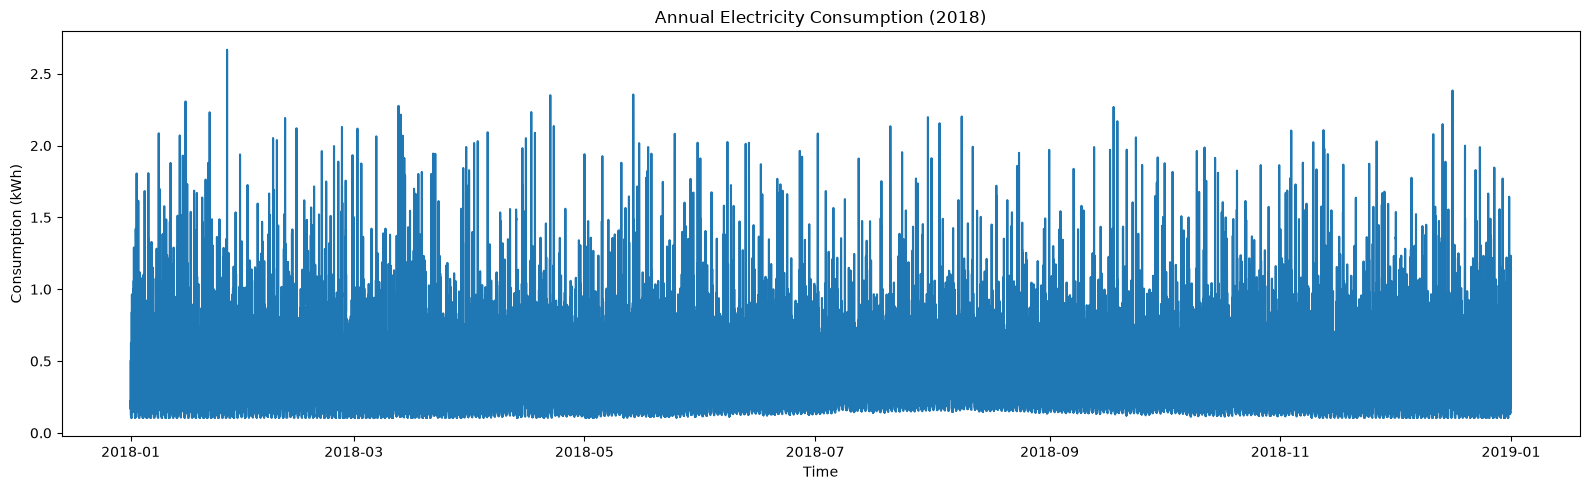

In [7]:
plt.figure(figsize=(16,5))

plt.plot(df["timestamp"], df[target])

plt.title("Annual Electricity Consumption (2018)")
plt.xlabel("Time")
plt.ylabel("Consumption (kWh)")

plt.tight_layout()
plt.show()


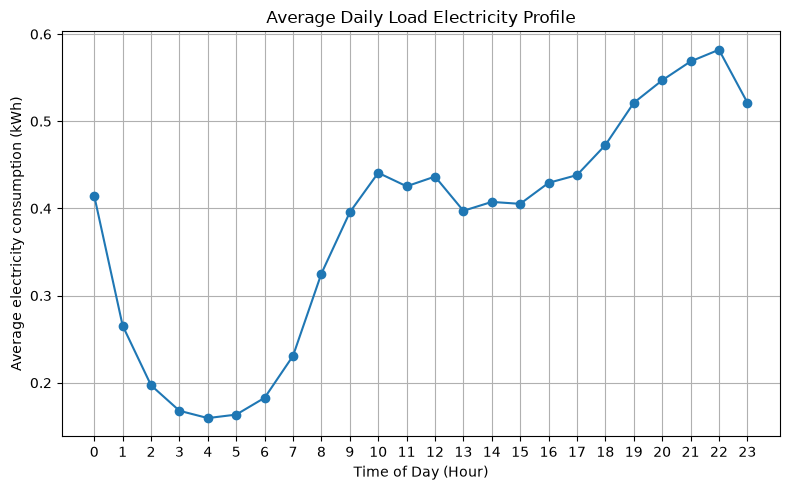

In [8]:
hourly = df.groupby("hour")[target].mean()

plt.figure(figsize=(8,5))

plt.plot(hourly.index, hourly.values, marker="o")

plt.xticks(range(24))

plt.title("Average Daily Load Electricity Profile")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average electricity consumption (kWh)")

plt.grid(True)

plt.tight_layout()
plt.show()


### Visualisation de l'évolution de la consommation d'énergie dans le temps

In [9]:
# Variable des ordonnées
TARGET1 = ["out.electricity.total.energy_consumption..kwh",
           "out.fuel_oil.total.energy_consumption..kwh",
           "out.natural_gas.total.energy_consumption..kwh",
           "out.propane.total.energy_consumption..kwh"]

df_1 = df.copy()
df_1[TARGET1] = df_1[TARGET1].apply(pd.to_numeric, errors='coerce')
df_1['out.total.energy_consumption'] = df_1[TARGET1].sum(axis=1)

df_1['out.total.energy_consumption'] 

0        0.22207
1        0.18771
2        0.16478
3        0.27735
4        0.50532
          ...   
35035    0.99951
35036    0.46611
35037    0.42904
35038    0.96009
35039    0.25418
Name: out.total.energy_consumption, Length: 35040, dtype: float32

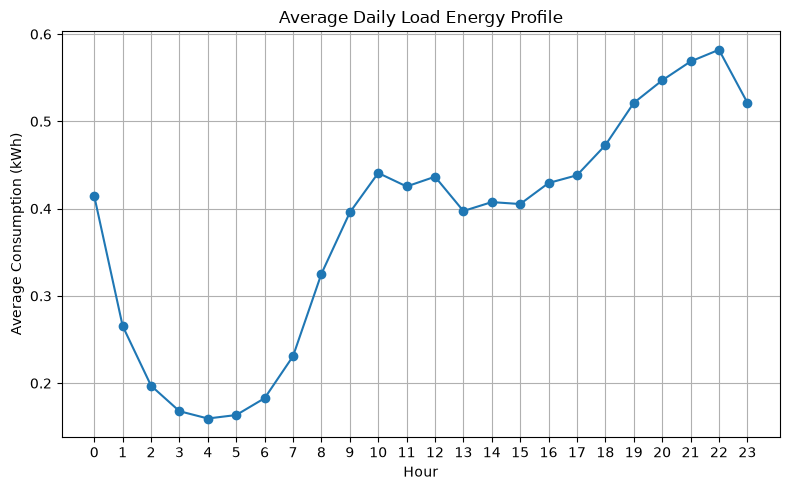

In [10]:
#Graphique 
hourly1 = df_1.groupby("hour")['out.total.energy_consumption'].mean()

plt.figure(figsize=(8,5))

plt.plot(hourly1.index, hourly1.values, marker="o")

plt.xticks(range(24))

plt.title("Average Daily Load Energy Profile")
plt.xlabel("Hour")
plt.ylabel("Average Consumption (kWh)")

plt.grid(True)

plt.tight_layout()
plt.show()

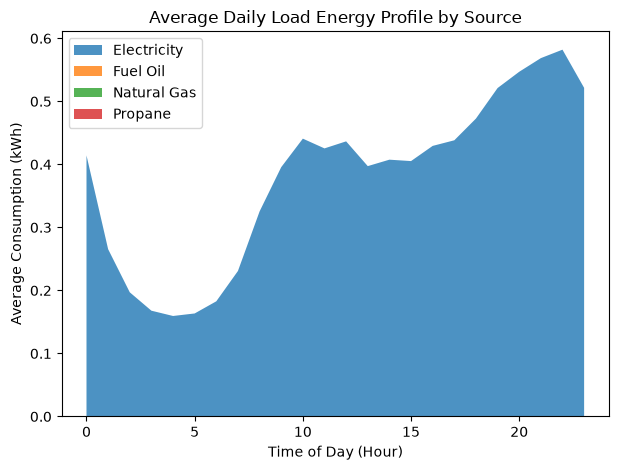

In [11]:
#Graphique stacked area chart

#Variables
x=range(24)
electricity = df_1.groupby("hour")['out.electricity.total.energy_consumption..kwh'].mean().values
fuel_oil = df_1.groupby("hour")['out.fuel_oil.total.energy_consumption..kwh'].mean().values
natural_gas = df_1.groupby("hour")['out.natural_gas.total.energy_consumption..kwh'].mean().values
propane = df_1.groupby("hour")['out.propane.total.energy_consumption..kwh'].mean().values
y=[electricity, fuel_oil, natural_gas, propane]

#Tracé 
plt.title("Average Daily Load Energy Profile by Source")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average Consumption (kWh)")
plt.tight_layout()
plt.stackplot(x,y, labels=['Electricity', 'Fuel Oil', 'Natural Gas', 'Propane'], alpha=0.8)
plt.legend(loc='upper left')
plt.show()


In [12]:
#Vérif si 'out.total.energy_consumption' == somme des consommations par motif d'utilisation 
#Création du dictionnaire des groupes de motifs d'utilisation


GROUPS = {
    "Confort thermique": {
        "color": "#E85D24",
        "cols": [
            "out.electricity.heating.energy_consumption..kwh",
            "out.electricity.heating_fans_pumps.energy_consumption..kwh",
            "out.electricity.heating_hp_bkup.energy_consumption..kwh",
            "out.electricity.heating_hp_bkup_fa.energy_consumption..kwh",
            "out.electricity.cooling.energy_consumption..kwh",
            "out.electricity.cooling_fans_pumps.energy_consumption..kwh",
            "out.natural_gas.heating.energy_consumption..kwh",
            "out.fuel_oil.heating.energy_consumption..kwh",
            "out.propane.heating.energy_consumption..kwh",
        ],
    },
    "Eau chaude sanitaire": {
        "color": "#378ADD",
        "cols": [
            "out.electricity.hot_water.energy_consumption..kwh",
            "out.electricity.hot_water_solar_th.energy_consumption..kwh",
            "out.natural_gas.hot_water.energy_consumption..kwh",
            "out.fuel_oil.hot_water.energy_consumption..kwh",
            "out.propane.hot_water.energy_consumption..kwh",
        ],
    },
    "Hygiène & nettoyage": {
        "color": "#1D9E75",
        "cols": [
            "out.electricity.clothes_washer.energy_consumption..kwh",
            "out.electricity.clothes_dryer.energy_consumption..kwh",
            "out.natural_gas.clothes_dryer.energy_consumption..kwh",
            "out.propane.clothes_dryer.energy_consumption..kwh",
            "out.electricity.dishwasher.energy_consumption..kwh",
        ],
    },
    "Alimentation": {
        "color": "#BA7517",
        "cols": [
            "out.electricity.range_oven.energy_consumption..kwh",
            "out.natural_gas.range_oven.energy_consumption..kwh",
            "out.propane.range_oven.energy_consumption..kwh",
            "out.electricity.refrigerator.energy_consumption..kwh",
            "out.electricity.freezer.energy_consumption..kwh",
            "out.natural_gas.grill.energy_consumption..kwh",
        ],
    },
    "Divertissement & loisirs": {
        "color": "#7F77DD",
        "cols": [
            "out.electricity.television.energy_consumption..kwh",
            "out.electricity.plug_loads.energy_consumption..kwh",
            "out.electricity.ceiling_fan.energy_consumption..kwh",
            "out.electricity.pool_pump.energy_consumption..kwh",
            "out.electricity.pool_heater.energy_consumption..kwh",
            "out.natural_gas.pool_heater.energy_consumption..kwh",
            "out.electricity.permanent_spa_pump.energy_consumption..kwh",
            "out.electricity.permanent_spa_heat.energy_consumption..kwh",
            "out.natural_gas.permanent_spa_heat.energy_consumption..kwh",
        ],
    },
    "Éclairage & ambiance": {
        "color": "#F2A623",
        "cols": [
            "out.electricity.lighting_interior.energy_consumption..kwh",
            "out.electricity.lighting_exterior.energy_consumption..kwh",
            "out.electricity.lighting_garage.energy_consumption..kwh",
            "out.natural_gas.lighting.energy_consumption..kwh",
            "out.natural_gas.fireplace.energy_consumption..kwh",
        ],
    },
    "Infrastructure": {
        "color": "#888780",
        "cols": [
            "out.electricity.mech_vent.energy_consumption..kwh",
            "out.electricity.well_pump.energy_consumption..kwh",
        ],
    },
}

TOTAL_COL = "out.site_energy.net.energy_consumption..kwh"
ELEC_NET  = "out.electricity.net.energy_consumption..kwh"
GAS_TOT   = "out.natural_gas.total.energy_consumption..kwh"
FUEL_TOT  = "out.fuel_oil.total.energy_consumption..kwh"
PROP_TOT  = "out.propane.total.energy_consumption..kwh"

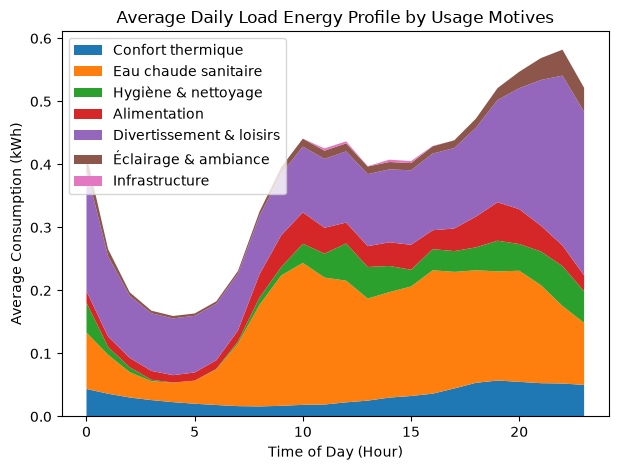

In [13]:
#Graphique stacked area chart by usage motive 

#Variables
x=range(24)
group_totals = { name: sum(df.groupby("hour")[c].mean().values for c in info["cols"]) for name, info in GROUPS.items()}
names = list(group_totals.keys())
y=[group_totals[n] for n in names]

#Tracé 
plt.title("Average Daily Load Energy Profile by Usage Motives")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average Consumption (kWh)")
plt.tight_layout()
plt.stackplot(x,y, labels=names, alpha=1, edgecolor='None')
plt.legend(loc='upper left')
plt.show()

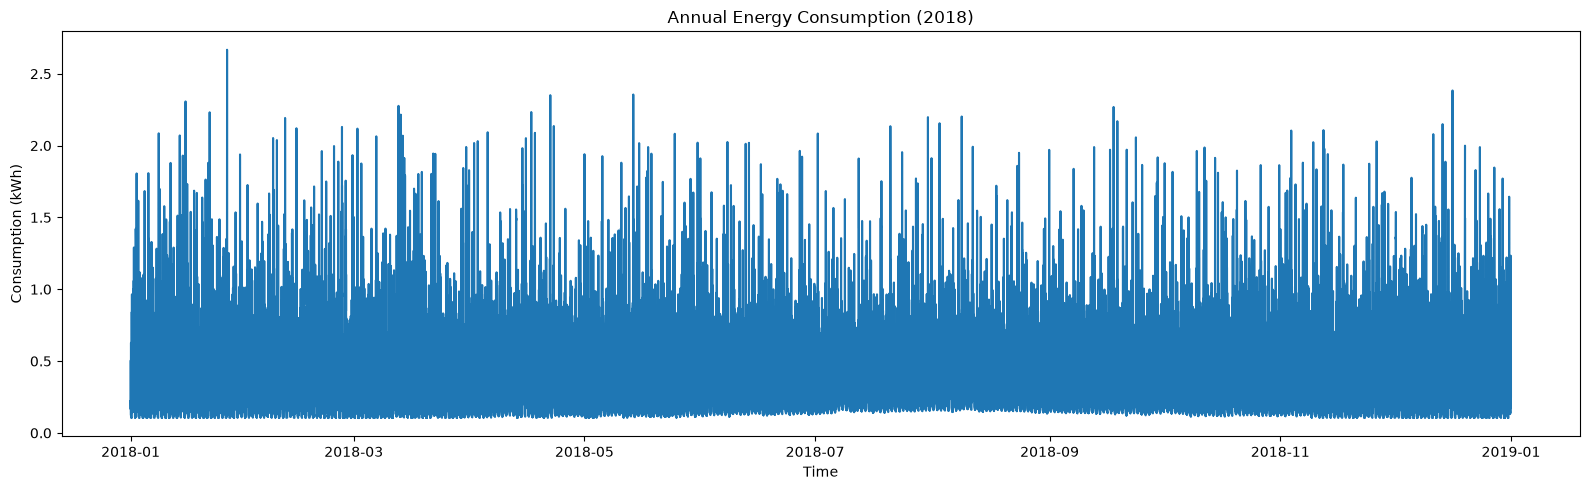

In [14]:
plt.figure(figsize=(16,5))
plt.plot(df_1["timestamp"], df_1['out.total.energy_consumption'])
plt.title("Annual Energy Consumption (2018)")
plt.xlabel("Time")
plt.ylabel("Consumption (kWh)")

plt.tight_layout()
plt.show()


### Vérification des caractéristiques du bâtiment

In [15]:
line_str = FILE[0:6]
bldg_line =df_metadata.loc[df_metadata['bldg_id'] == int(line_str) ,:]

print("Nombre d'étages : " + str(bldg_line['in.geometry_stories'].iloc[0]))

if bldg_line['in.misc_pool'].iloc[0] == 'Has Pool' :
    print('Il y a une piscine')
else:
    print("Il n'y a pas de piscine")

if bldg_line['in.electric_vehicle_ownership'].iloc[0]==0:
    print("Il n'y a pas de véhicule électrique")
else:
    print('Il y a un véhicule électrique')

if bldg_line['in.has_pv'].iloc[0]==0:
    print("Il n'y a pas de panneau solaire")
else:
    print("Il y a au moins un panneau solaire")

if bldg_line['in.hvac_heating_type'].iloc[0]=='None':
    print("Il n'y a pas de chauffage")
else:
    print("Il y a du chauffage")
    if bldg_line['out.electricity.heating.energy_consumption..kwh'].iloc[0]==0:
        print("Il n'y a pas de chauffage électrique")
    else:
        print("Ce chauffage est électrique")

non_electric_sources = fuel_oil.sum() + natural_gas.sum()+propane.sum()
if non_electric_sources == 0 and electricity.sum() != 0:
    print("La seule source d'énergie est l'électricité")
else:
    print("L'électricité n'est pas la seule source d'énergie.")

print("Il y a "+str(round(bldg_line['in.occupants'].iloc[0]))+" habitants dans ce bâtiment.")

Nombre d'étages : 1
Il n'y a pas de piscine
Il n'y a pas de véhicule électrique
Il n'y a pas de panneau solaire
Il y a du chauffage
Ce chauffage est électrique
La seule source d'énergie est l'électricité
Il y a 5 habitants dans ce bâtiment.


In [16]:
bldg_line['in.corridor'].iloc[0]

'Double-Loaded Interior'

### Visualisations climatiques

In [17]:
df_1.groupby("hour")['out.total.energy_consumption'].mean()

hour
0     0.414258
1     0.265454
2     0.197057
3     0.167879
4     0.159494
5     0.163484
6     0.182773
7     0.230896
8     0.325348
9     0.395580
10    0.440855
11    0.425394
12    0.436553
13    0.397265
14    0.407473
15    0.405255
16    0.429339
17    0.438233
18    0.472693
19    0.521133
20    0.546953
21    0.568607
22    0.582022
23    0.521450
Name: out.total.energy_consumption, dtype: float32

In [18]:
# Variables utiles pour graphique 
occupancy = 'out.schedules.occupants'
#surface = 'in.sqft'
heating_consumption = ['out.electricity.heating.energy_consumption..kwh',
                       'out.electricity.heating_fans_pumps.energy_consumption..kwh',
                       'out.electricity.heating_hp_bkup.energy_consumption..kwh',
                       'out.electricity.heating_hp_bkup_fa.energy_consumption..kwh',
                       'out.natural_gas.heating.energy_consumption..kwh',
                       'out.fuel_oil.heating.energy_consumption..kwh',
                       'out.propane.heating.energy_consumption..kwh']
ac_consumption = ['out.electricity.cooling.energy_consumption..kwh',
                  'out.electricity.cooling_fans_pumps.energy_consumption..kwh']
temperature = 'out.outdoor_air_drybulb_temp..c'
outdoor_humidity_percentage = 'out.outdoor_air_relative_humidity..percentage'
outdoor_humidity_ratio = 'out.outdoor_humidity_ratio..kgwater_per_kgdryair'
sun_radiation = 'out.weather.direct_normal_solar_radiation..watt_per_m2'
energy = 'out.total.energy_consumption'

#Création du dataframe pour le heatmap
df_2 =df_1.copy()
df_2[heating_consumption] = df_2[heating_consumption].apply(pd.to_numeric, errors='coerce')
df_2['out.total.heating_consumption'] = df_1[heating_consumption].sum(axis=1)
df_2[ac_consumption] = df_2[ac_consumption].apply(pd.to_numeric, errors='coerce')
df_2['out.total.cooling_consumption'] = df_1[ac_consumption].sum(axis=1)

total_heating_consumption = 'out.total.heating_consumption'
total_cooling_consumption = 'out.total.cooling_consumption'

cols_to_keep = [occupancy, total_heating_consumption, total_cooling_consumption, energy, temperature, outdoor_humidity_percentage, outdoor_humidity_ratio, sun_radiation]

df_2hourly = df_2.groupby("hour")[cols_to_keep].mean()
df_2hourly


,out.schedules.occupants,out.total.heating_consumption,out.total.cooling_consumption,out.total.energy_consumption,out.outdoor_air_drybulb_temp..c,out.outdoor_air_relative_humidity..percentage,out.outdoor_humidity_ratio..kgwater_per_kgdryair,out.weather.direct_normal_solar_radiation..watt_per_m2
hour,,,,,,,,
0,0.965205,0.000000,0.043643,0.414258,16.660034,68.694855,0.008516,0.000000
1,0.976822,0.000000,0.036147,0.265454,16.315746,69.678894,0.008471,0.000000
2,0.983260,0.000000,0.030113,0.197057,16.071955,70.179871,0.008427,0.000000
3,0.985918,0.000000,0.026031,0.167879,15.862352,70.519379,0.008377,0.000000
4,0.987452,0.000000,0.022771,0.159494,15.677870,70.756035,0.008319,0.000000
5,0.988356,0.000000,0.020287,0.163484,15.563406,70.848877,0.008291,0.000000
6,0.976904,0.000000,0.018241,0.182773,15.501687,70.742516,0.008260,0.000000
7,0.958658,0.000000,0.016450,0.230896,15.407302,70.662445,0.008214,0.525429
8,0.914849,0.000184,0.015829,0.325348,15.448279,70.262283,0.008204,37.843548


In [19]:
names1 = ['Occupancy', 'Heating consumption', 'Cooling consumption', 'Total Consumption', 'Temperature', 'Outdoor humidity (%)', 'Outdoor humidity (ratio)', 'Sun radiation']
names1

['Occupancy',
 'Heating consumption',
 'Cooling consumption',
 'Total Consumption',
 'Temperature',
 'Outdoor humidity (%)',
 'Outdoor humidity (ratio)',
 'Sun radiation']

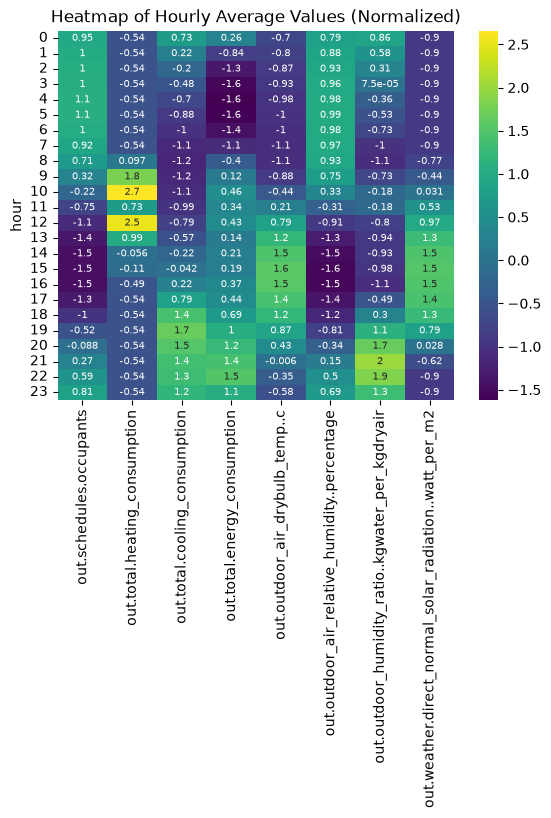

In [20]:
#Créer un heatmap 
import seaborn as sns

df_2hourly_norm=(df_2hourly-df_2hourly.mean())/df_2hourly.std()     #normalisation pour éviter que la variable de radiation domine
sns.heatmap(df_2hourly_norm, cmap='viridis',annot=True, annot_kws={"size": 7})
plt.title("Heatmap of Hourly Average Values (Normalized)")
plt.show()


In [21]:
bldg_line['in.county']

100270    G0600730
Name: in.county, dtype: str

Objectif --> heatmap avec blocs par niveaux de consommation (bas, moyen, haut)

In [22]:
df_1.groupby("hour")['out.total.energy_consumption'].mean()

hour
0     0.414258
1     0.265454
2     0.197057
3     0.167879
4     0.159494
5     0.163484
6     0.182773
7     0.230896
8     0.325348
9     0.395580
10    0.440855
11    0.425394
12    0.436553
13    0.397265
14    0.407473
15    0.405255
16    0.429339
17    0.438233
18    0.472693
19    0.521133
20    0.546953
21    0.568607
22    0.582022
23    0.521450
Name: out.total.energy_consumption, dtype: float32

In [23]:
df_1.shape[0]

35040

In [24]:
#créer chunks de temps dans la journée en fonction de la courbe (basse, moyenne, haute consommation)
low = df_1.groupby("hour")['out.total.energy_consumption'].mean().quantile(0.33)
medium = df_1.groupby("hour")['out.total.energy_consumption'].mean().quantile(0.66)

LOWX = [i for i in range(24) if df_1.groupby('hour')['out.total.energy_consumption'].mean().iloc[i] <= low]
LOWY = [df_1.groupby("hour")['out.total.energy_consumption'].mean().iloc[i] for i in LOWX]
MEDIUMX = [i for i in range(24) if low < df_1.groupby("hour")['out.total.energy_consumption'].mean().iloc[i] <= medium]
MEDIUMY = [df_1.groupby("hour")['out.total.energy_consumption'].mean().iloc[i] for i in MEDIUMX]
HIGHX = [i for i in range(24) if df_1.groupby("hour")['out.total.energy_consumption'].mean().iloc[i] > medium]
HIGHY = [df_1.groupby("hour")['out.total.energy_consumption'].mean().iloc[i] for i in HIGHX]

print("Basse consommation : ", LOWX, LOWY)
print("Moyenne consommation : ", MEDIUMX, MEDIUMY)
print("Haute consommation : ", HIGHX, HIGHY)

Basse consommation :  [1, 2, 3, 4, 5, 6, 7, 8] [np.float32(0.26545447), np.float32(0.1970565), np.float32(0.16787891), np.float32(0.15949365), np.float32(0.16348438), np.float32(0.18277274), np.float32(0.23089625), np.float32(0.32534757)]
Moyenne consommation :  [0, 9, 11, 12, 13, 14, 15, 16] [np.float32(0.41425753), np.float32(0.39558038), np.float32(0.42539376), np.float32(0.43655324), np.float32(0.39726463), np.float32(0.407473), np.float32(0.40525466), np.float32(0.4293391)]
Haute consommation :  [10, 17, 18, 19, 20, 21, 22, 23] [np.float32(0.44085473), np.float32(0.4382335), np.float32(0.4726933), np.float32(0.5211326), np.float32(0.54695266), np.float32(0.568607), np.float32(0.582022), np.float32(0.52145)]


In [25]:
print(low,medium)

0.36678492963314063 0.436855685710907


In [26]:
df_2_blocs = df_2.copy(deep=True)
df_2_blocs['blocs']= 0
#df_2_blocs = df_2_blocs.astype({'blocs': float})

"""low_mean = sum(LOWY)/len(LOWY)
medium_mean = sum(MEDIUMY)/len(MEDIUMY)
high_mean = sum(HIGHY)/len(HIGHY)

Bloc_low = {LOWX[i] : low_mean for i in range(len(LOWX))}
Bloc_medium = {MEDIUMX[i] : medium_mean for i in range(len(MEDIUMX))}
Bloc_high = {HIGHX[i] : high_mean for i in range(len(HIGHX))}

for hour,value in Bloc_low.items():
    df_2_blocs.loc['hour','blocs'] = value
df_2_blocs
Bloc_low
"""
col_nb = df_1.shape[0]

for i in range(col_nb):
    if df_2_blocs.loc[i,'hour'] in LOWX:
        df_2_blocs.loc[i,'blocs'] = 1
    elif df_2_blocs.loc[i,'hour'] in MEDIUMX:
        df_2_blocs.loc[i,'blocs'] = 2
    else:
        df_2_blocs.loc[i,'blocs'] = 3

df_2_blocs = df_2_blocs.groupby('blocs')[cols_to_keep].mean()
df_2_blocs

,out.schedules.occupants,out.total.heating_consumption,out.total.cooling_consumption,out.total.energy_consumption,out.outdoor_air_drybulb_temp..c,out.outdoor_air_relative_humidity..percentage,out.outdoor_humidity_ratio..kgwater_per_kgdryair,out.weather.direct_normal_solar_radiation..watt_per_m2
blocs,,,,,,,,
1,0.971527,0.000023,0.023234,0.211548,15.731074,70.456291,0.008320,4.796122
2,0.602075,0.000330,0.027923,0.413890,21.356775,52.101856,0.008281,490.987274
3,0.728760,0.000115,0.047862,0.511493,20.193657,56.993793,0.008530,311.363983


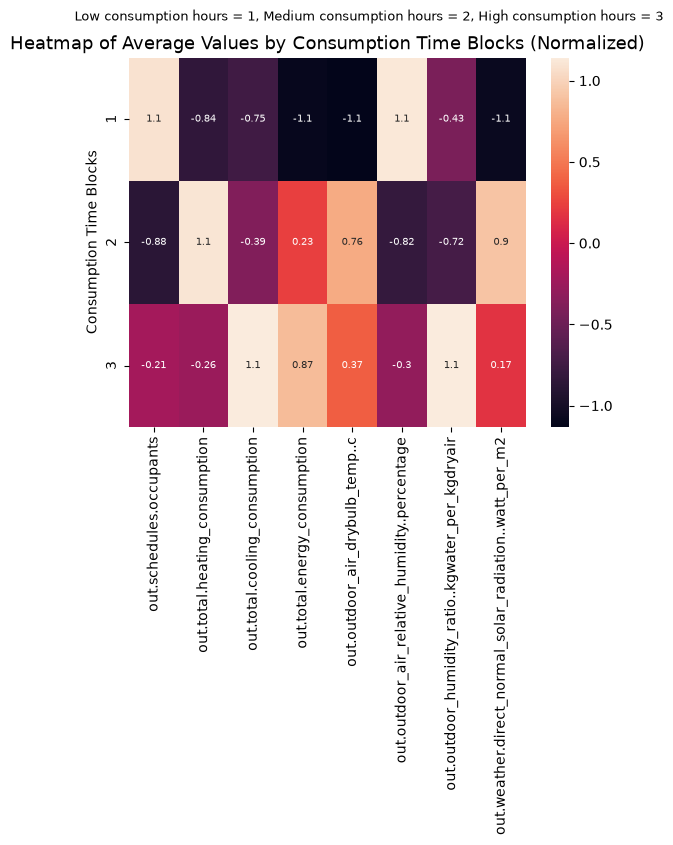

In [27]:
df_2_blocs_norm=(df_2_blocs-df_2_blocs.mean())/df_2_blocs.std()     #normalisation pour éviter que la variable de radiation domine
sns.heatmap(df_2_blocs_norm, annot=True, annot_kws={"size": 7})
plt.suptitle("Low consumption hours = 1, Medium consumption hours = 2, High consumption hours = 3", fontsize=9)
plt.title("Heatmap of Average Values by Consumption Time Blocks (Normalized)", fontsize=13)
plt.ylabel("Consumption Time Blocks")
plt.show()

### Visualisation de l'occupation du bâtiment en fonction du temps sur 1 journée

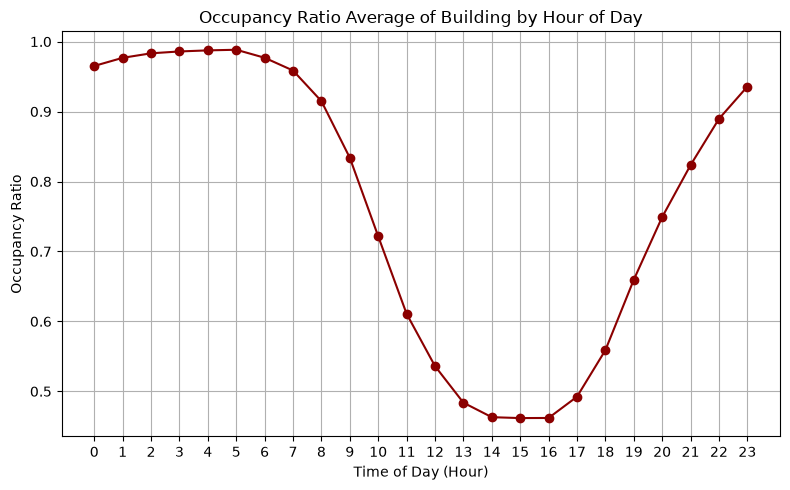

In [28]:
hourly = df.groupby("hour")[occupancy].mean()

plt.figure(figsize=(8,5))

plt.plot(hourly.index, hourly.values, marker="o", color='darkred')

plt.xticks(range(24))

plt.title("Occupancy Ratio Average of Building by Hour of Day")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Occupancy Ratio")

plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
hourly

hour
0     0.965205
1     0.976822
2     0.983260
3     0.985918
4     0.987452
5     0.988356
6     0.976904
7     0.958658
8     0.914849
9     0.833890
10    0.721644
11    0.610822
12    0.536082
13    0.483808
14    0.463069
15    0.461781
16    0.461945
17    0.492301
18    0.558822
19    0.659479
20    0.749123
21    0.823452
22    0.889562
23    0.935699
Name: out.schedules.occupants, dtype: float32

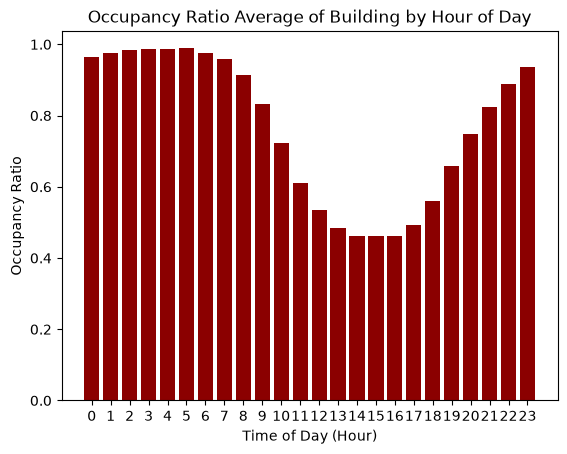

In [30]:
height = hourly.values
bars = hourly.index
y_pos = np.arange(len(bars))

plt.bar(y_pos, height, color='darkred')
plt.xticks(y_pos, bars)

plt.title("Occupancy Ratio Average of Building by Hour of Day")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Occupancy Ratio")

plt.show()


In [31]:
hourly

hour
0     0.965205
1     0.976822
2     0.983260
3     0.985918
4     0.987452
5     0.988356
6     0.976904
7     0.958658
8     0.914849
9     0.833890
10    0.721644
11    0.610822
12    0.536082
13    0.483808
14    0.463069
15    0.461781
16    0.461945
17    0.492301
18    0.558822
19    0.659479
20    0.749123
21    0.823452
22    0.889562
23    0.935699
Name: out.schedules.occupants, dtype: float32

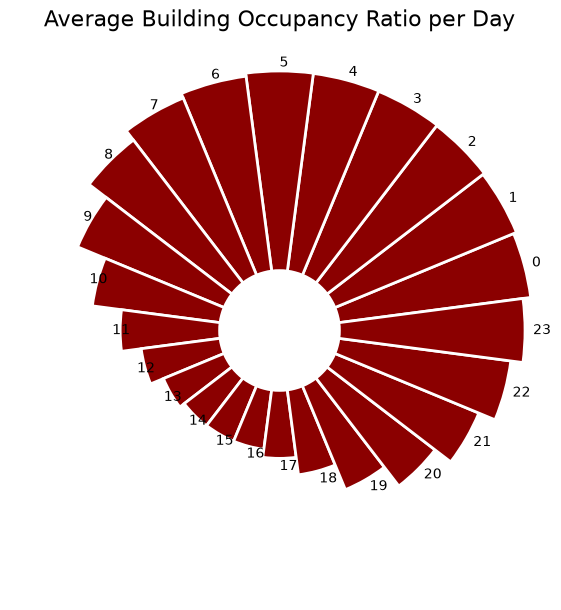

In [32]:
plt.figure(figsize=(15,7))
ax = plt.subplot(111, polar=True)
plt.axis('off')
upperLimit = 100
lowerLimit = 30

# paramètres
min_val = hourly.values.min()
max_val = hourly.values.max()
heights = lowerLimit + (hourly.values-min_val) / (max_val - min_val)*(upperLimit - lowerLimit)
width = 2*np.pi / len(hourly.index)

# angle de centrage
indexes = list(range(1, len(hourly.index)+1))
angles = [element * width for element in indexes]
angles

# barres
bars = ax.bar(
    x=angles, 
    height=heights, 
    width=width, 
    bottom=lowerLimit,
    linewidth=2,
    color='darkred', 
    edgecolor="white")

#étiquettes
labelPadding = 4
for bar, angle, height, label in zip(bars,angles, heights, hourly.index):
    ax.text(
        x=angle, 
        y=lowerLimit + bar.get_height() + labelPadding, 
        s=label, 
        va='center', 
        rotation_mode="anchor") 

plt.title("Average Building Occupancy Ratio per Day", fontsize = 16)
plt.show()

 ### Visualisation de la consommation dans le temps 


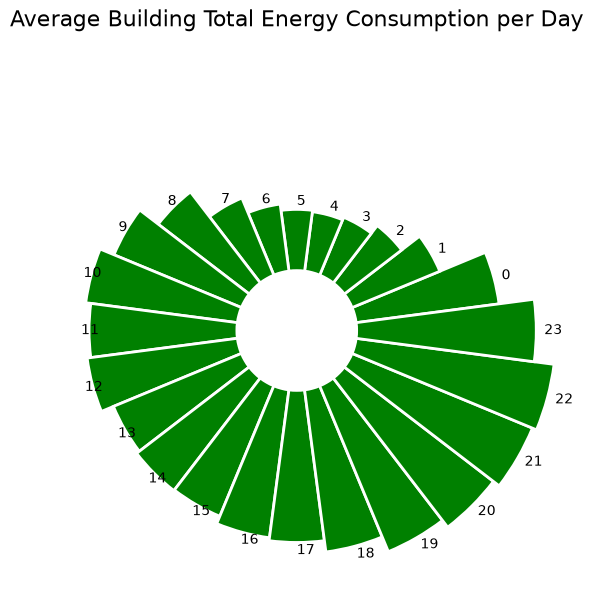

In [33]:
hourly = df_1.groupby("hour")['out.total.energy_consumption'].mean()
plt.figure(figsize=(15,7))
ax = plt.subplot(111, polar=True)
plt.axis('off')
upperLimit = 100
lowerLimit = 30

# paramètres
min_val = hourly.values.min()
max_val = hourly.values.max()
heights = lowerLimit + (hourly.values-min_val) / (max_val - min_val)*(upperLimit - lowerLimit)
width = 2*np.pi / len(hourly.index)

# angle de centrage
indexes = list(range(1, len(hourly.index)+1))
angles = [element * width for element in indexes]
angles

# barres
bars = ax.bar(
    x=angles, 
    height=heights, 
    width=width, 
    bottom=lowerLimit,
    linewidth=2,
    color='green', 
    edgecolor="white")

#étiquettes
labelPadding = 4
for bar, angle, height, label in zip(bars,angles, heights, hourly.index):
    ax.text(
        x=angle, 
        y=lowerLimit + bar.get_height() + labelPadding, 
        s=label, 
        va='center', 
        rotation_mode="anchor") 

plt.title("Average Building Total Energy Consumption per Day", fontsize = 16)
plt.show()

In [34]:
for col in df_2.columns :
    if col not in df :
        print(col)
        

out.total.energy_consumption
out.total.heating_consumption
out.total.cooling_consumption


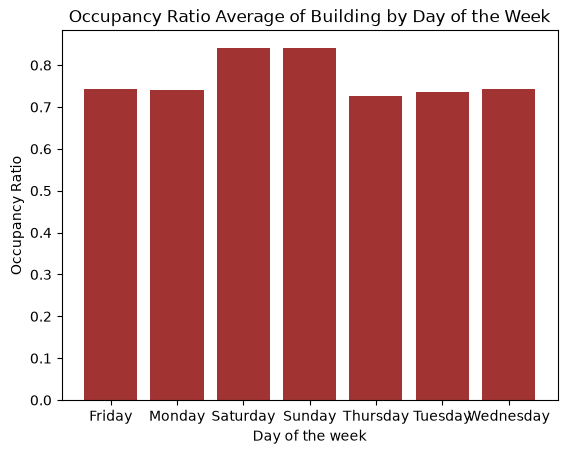

In [35]:
#occupancy per day 
df_week = df.groupby('day')[occupancy].mean()
"""height = 
bars = hourly.index
y_pos = np.arange(len(bars))"""

plt.bar(df_week.index, df_week.values, color='darkred', alpha=0.8)
#plt.xticks(df_week.values, df_week.index)

plt.title("Occupancy Ratio Average of Building by Day of the Week")
plt.xlabel("Day of the week")
plt.ylabel("Occupancy Ratio")

plt.show()


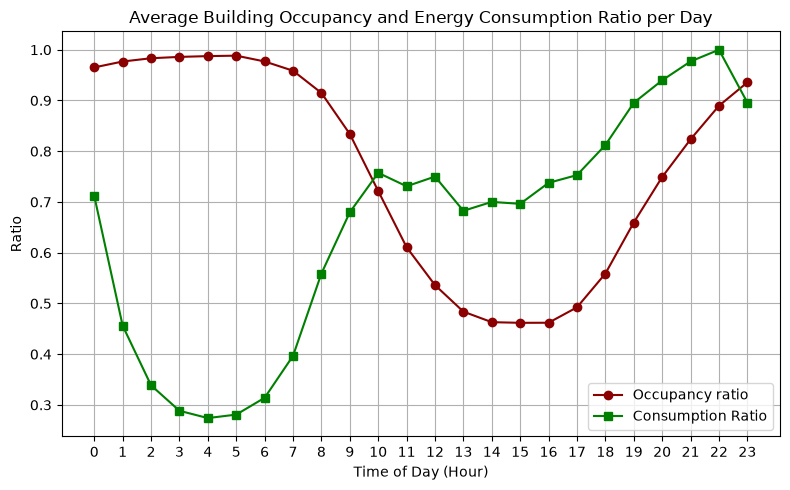

In [36]:

hourly_occupancy = df.groupby("hour")[occupancy].mean()
hourly_energy = df_1.groupby("hour")['out.total.energy_consumption'].mean()

plt.figure(figsize=(8,5))

plt.plot(hourly_occupancy.index, hourly_occupancy.values, marker="o", color='darkred', label='Occupancy ratio')
plt.plot(hourly_energy.index, hourly_energy.values/hourly_energy.values.max(), marker='s', color='green', label='Consumption Ratio')

plt.xticks(range(24))

plt.title("Average Building Occupancy and Energy Consumption Ratio per Day")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Ratio")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
line_100276 =df_metadata.loc[df_metadata['bldg_id'] == 100276 ,:]
line_100276['in.income']
income = line_100276['in.income'].iloc[0]
income

np.float64(64999.5)

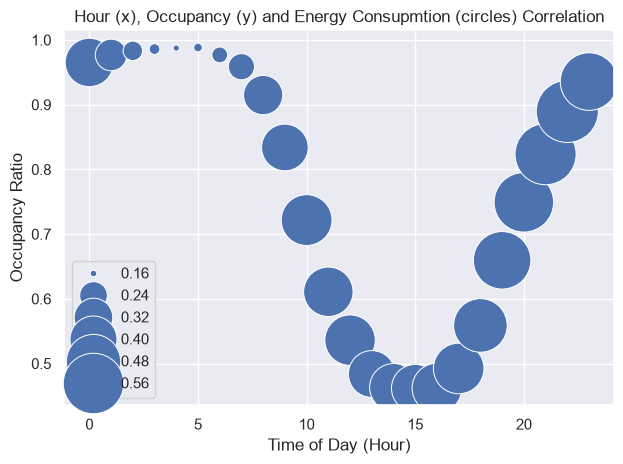

In [38]:
keep_scatter = ['out.total.energy_consumption', occupancy] 
hourly_scatterplot = df_1.groupby("hour")[keep_scatter].mean()

sns.set_theme(style="darkgrid")
sns.scatterplot(data=hourly_scatterplot, x='hour', y=occupancy, size='out.total.energy_consumption', legend='auto', sizes=(20, 2000))

plt.title("Hour (x), Occupancy (y) and Energy Consupmtion (circles) Correlation")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Occupancy Ratio")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
plt.show()

### Visualisation de la correlation entre le temps et les autes variables

In [39]:
#Variables

temperature_regulation = GROUPS['Confort thermique']['cols']
hot_water = GROUPS['Eau chaude sanitaire']['cols']
hygiene = GROUPS['Hygiène & nettoyage']['cols']
food = GROUPS['Alimentation']['cols']
leisure = GROUPS['Divertissement & loisirs']['cols']
lighting = GROUPS['Éclairage & ambiance']['cols']
#electric_vehicle = GROUPS['Mobilité (VE)']['cols']
infrastructure = GROUPS['Infrastructure']['cols']
#solar_panel_production = GROUPS['Production PV']['cols']

#Création du dataframe pour le heatmap
df_3 =df_1.copy()

df_3[temperature_regulation] = df_1[temperature_regulation].apply(pd.to_numeric, errors='coerce')
df_3['out.total.temperature_regulation_consumption'] = df_3[temperature_regulation].sum(axis=1)
df_3[hot_water] = df_1[hot_water].apply(pd.to_numeric, errors='coerce')
df_3['out.total.hot_water_consumption'] = df_3[hot_water].sum(axis=1)
df_3[hygiene] = df_1[hygiene].apply(pd.to_numeric, errors='coerce')
df_3['out.total.hygiene_consumption'] = df_3[hygiene].sum(axis=1)
df_3[food] = df_1[food].apply(pd.to_numeric, errors='coerce')
df_3['out.total.food_consumption'] = df_3[food].sum(axis=1)
df_3[leisure] = df_1[leisure].apply(pd.to_numeric, errors='coerce')
df_3['out.total.leisure_consumption'] = df_3[leisure].sum(axis=1)
df_3[lighting] = df_1[lighting].apply(pd.to_numeric, errors='coerce')
df_3['out.total.lighting_consumption'] = df_3[lighting].sum(axis=1)
#df_3[electric_vehicle] = df_1[electric_vehicle].apply(pd.to_numeric, errors='coerce')
#df_3['out.total.electric_vehicle_consumption'] = df_3[electric_vehicle].sum(axis=1)
df_3[infrastructure] = df_1[infrastructure].apply(pd.to_numeric, errors='coerce')
df_3['out.infrastructure_consumption'] = df_3[infrastructure].sum(axis=1)
#df_3[solar_panel_production] = df_1[solar_panel_production].apply(pd.to_numeric, errors='coerce')
#df_3['out.solar_panel_production_consumption'] = df_3[solar_panel_production].sum(axis=1)

df_3

,bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,...,month,date,out.total.energy_consumption,out.total.temperature_regulation_consumption,out.total.hot_water_consumption,out.total.hygiene_consumption,out.total.food_consumption,out.total.leisure_consumption,out.total.lighting_consumption,out.infrastructure_consumption
0,100276,2018-01-01 00:15:00,1138.0,0.00180,0.0,0.0,0.0,0.0,0.0,0.0,...,1,2018-01-01,0.22207,0.0,0.00000,0.0,0.01304,0.19222,0.01681,0.0
1,100276,2018-01-01 00:30:00,1138.0,0.00216,0.0,0.0,0.0,0.0,0.0,0.0,...,1,2018-01-01,0.18771,0.0,0.00000,0.0,0.01301,0.16146,0.01324,0.0
2,100276,2018-01-01 00:45:00,1138.0,0.00240,0.0,0.0,0.0,0.0,0.0,0.0,...,1,2018-01-01,0.16478,0.0,0.00000,0.0,0.01297,0.14095,0.01087,0.0
3,100276,2018-01-01 01:00:00,1138.0,0.00204,0.0,0.0,0.0,0.0,0.0,0.0,...,1,2018-01-01,0.27735,0.0,0.10311,0.0,0.01293,0.14790,0.01341,0.0
4,100276,2018-01-01 01:15:00,1138.0,0.00180,0.0,0.0,0.0,0.0,0.0,0.0,...,1,2018-01-01,0.50532,0.0,0.32552,0.0,0.01223,0.15276,0.01482,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,100276,2018-12-31 23:00:00,1138.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,12,2018-12-31,0.99951,0.0,0.58109,0.0,0.01439,0.35428,0.04976,0.0
35036,100276,2018-12-31 23:15:00,1138.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,12,2018-12-31,0.46611,0.0,0.03708,0.0,0.01377,0.36979,0.04547,0.0
35037,100276,2018-12-31 23:30:00,1138.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,12,2018-12-31,0.42904,0.0,0.00000,0.0,0.01378,0.36979,0.04547,0.0
35038,100276,2018-12-31 23:45:00,1138.0,0.00072,0.0,0.0,0.0,0.0,0.0,0.0,...,12,2018-12-31,0.96009,0.0,0.60796,0.0,0.01378,0.30256,0.03580,0.0


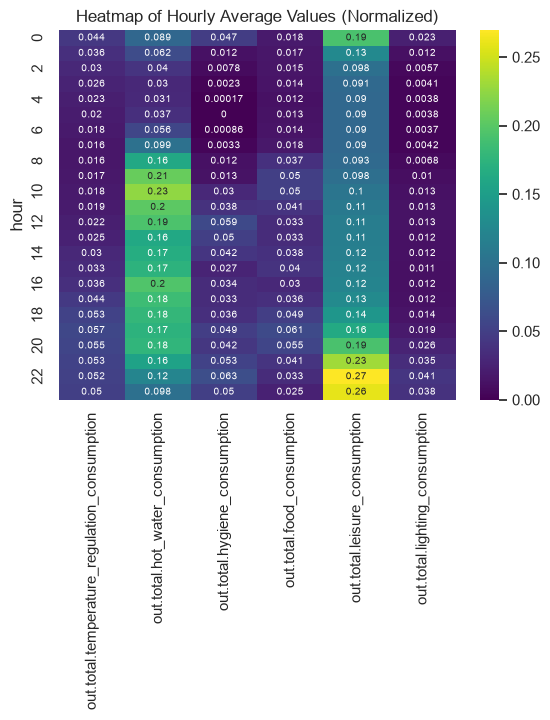

In [40]:
cols_to_keep3=[]
cols_to_keep3 = ['out.total.temperature_regulation_consumption', 
                  'out.total.hot_water_consumption',
                  'out.total.hygiene_consumption', 
                  'out.total.food_consumption', 
                  'out.total.leisure_consumption', 
                  'out.total.lighting_consumption', 
                  #occupancy,
                  #'out.total.energy_consumption'
                  ]

df_3hourly = df_3.groupby('hour')[cols_to_keep3].mean()
df_3hourly_norm = (df_3hourly-df_3hourly.mean())/df_3hourly.std()
sns.heatmap(df_3hourly, cmap='viridis',annot=True, annot_kws={"size": 7})
plt.title("Heatmap of Hourly Average Values (Normalized)")
plt.show()

### Visualisation de la température interieure moyenne du bâtiment sur une journée

In [41]:
df_2["minute"] = df_2["timestamp"].dt.minute + df_2["timestamp"].dt.hour*60
keep = ['out.indoor_temperature.conditioned_space..c', 'out.total.cooling_consumption']
df_2minutely_temp = df_2.groupby('minute')['out.indoor_temperature.conditioned_space..c'].mean()
df_2minutely_cool = df_2.groupby('minute')['out.total.cooling_consumption'].mean()

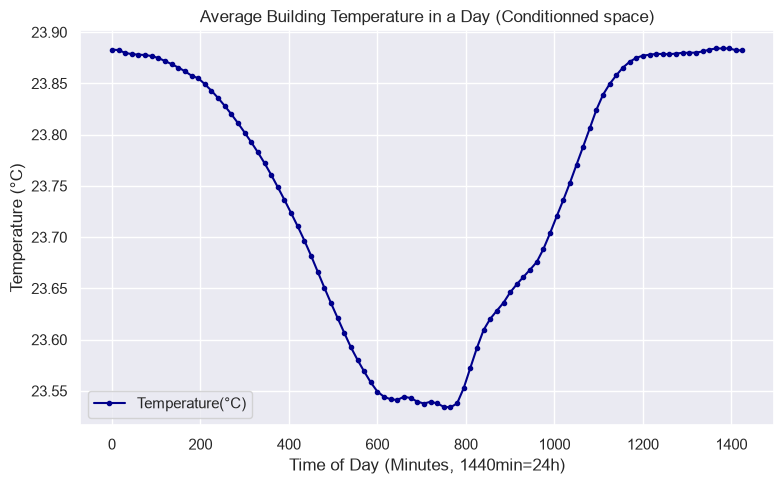

In [42]:
plt.figure(figsize=(8,5))

plt.plot(df_2minutely_temp.index, df_2minutely_temp.values, marker=".", color='darkblue', label='Temperature(°C)')

plt.title("Average Building Temperature in a Day (Conditionned space)")
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

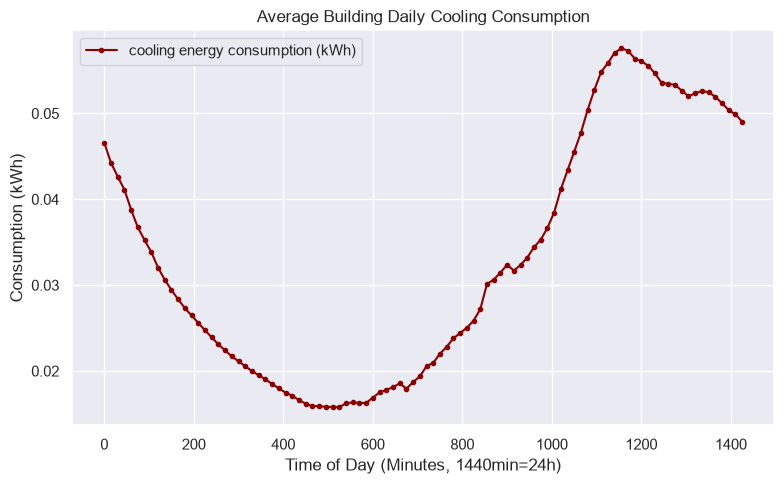

In [43]:
plt.figure(figsize=(8,5))

plt.plot(df_2minutely_cool.index, df_2minutely_cool.values, marker=".", color='darkred', label='cooling energy consumption (kWh)')

plt.title("Average Building Daily Cooling Consumption")
plt.xlabel("Time of Day (Minutes, 1440min=24h)")
plt.ylabel("Consumption (kWh)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

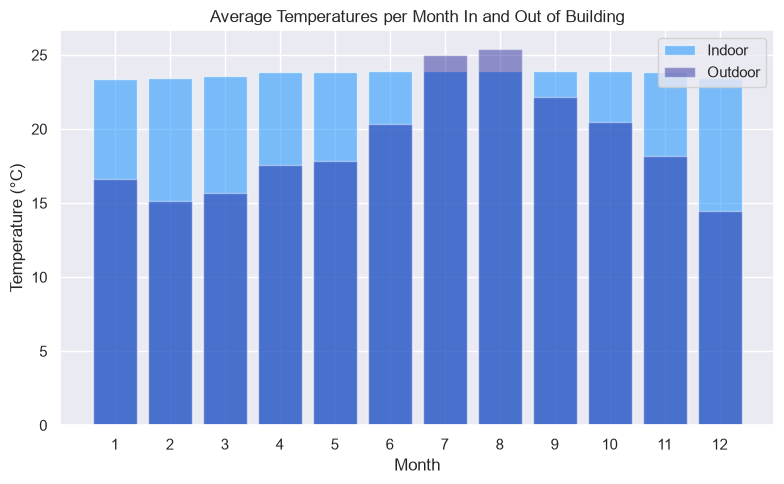

In [44]:
df_months_indoor_temp = df.groupby('month')['out.indoor_temperature.conditioned_space..c'].mean()
df_months_outdoor_temp = df.groupby('month')['out.outdoor_air_drybulb_temp..c'].mean()

plt.figure(figsize=(8,5))

plt.bar(df_months_indoor_temp.index, df_months_indoor_temp.values, color='#2E9CFF', label='Indoor', alpha=0.6)
plt.bar(df_months_outdoor_temp.index, df_months_outdoor_temp.values, color='darkblue', label='Outdoor', alpha=0.4)

plt.xticks(range(1,13))
plt.title("Average Temperatures per Month In and Out of Building")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\eassoumou1\AppData\Local\Temp\ipykernel_22084\941600605.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


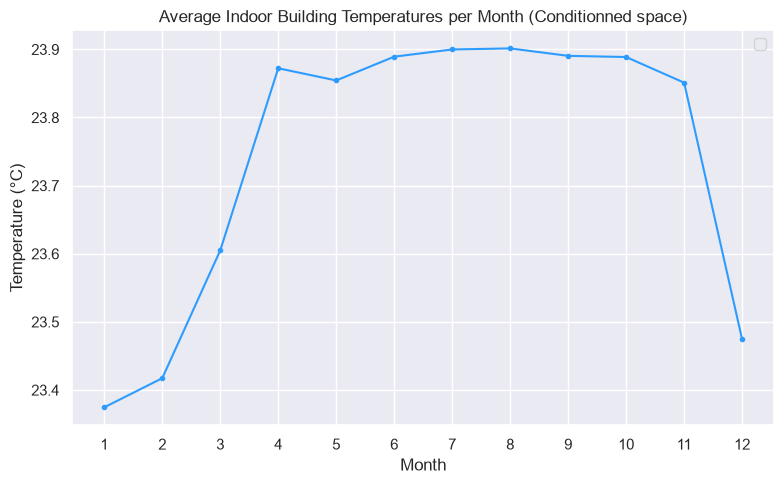

In [45]:
plt.figure(figsize=(8,5))

plt.plot(df_months_indoor_temp.index, df_months_indoor_temp.values, marker=".", color='#2E9CFF')

plt.xticks(range(1,13))
plt.title("Average Indoor Building Temperatures per Month (Conditionned space)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
print('Building heating setpoint : ' + str(bldg_line['in.heating_setpoint'].iloc[0]) + '°C')
print('Building cooling setpoint : ' + str(bldg_line['in.cooling_setpoint'].iloc[0]) + '°C')

Building heating setpoint : 21.1°C
Building cooling setpoint : 23.9°C


C:\Users\eassoumou1\AppData\Local\Temp\ipykernel_22084\3564503078.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


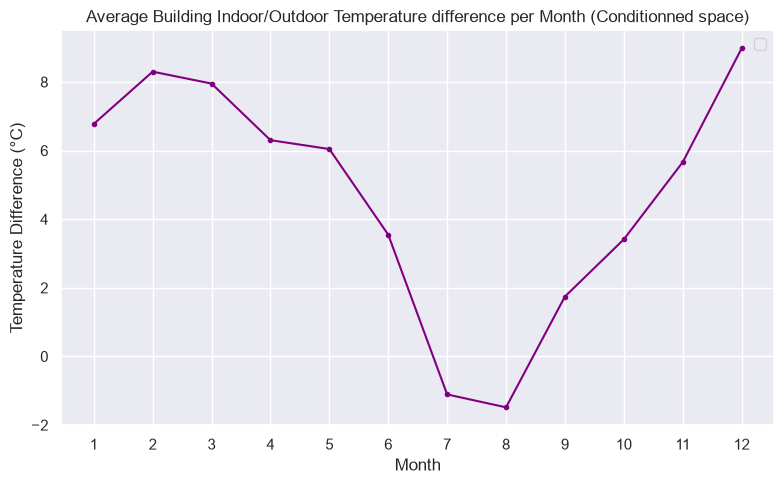

In [47]:
plt.figure(figsize=(8,5))

plt.plot(df_months_indoor_temp.index, df_months_indoor_temp.values-df_months_outdoor_temp.values, marker=".", color='purple')

plt.xticks(range(1,13))
plt.title("Average Building Indoor/Outdoor Temperature difference per Month (Conditionned space)")
plt.xlabel("Month")
plt.ylabel("Temperature Difference (°C)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Visualisation du lien entre température à l'intérieur et revenu (fichier metadata, pas time series)

C:\Users\eassoumou1\AppData\Local\Temp\ipykernel_22084\848541156.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


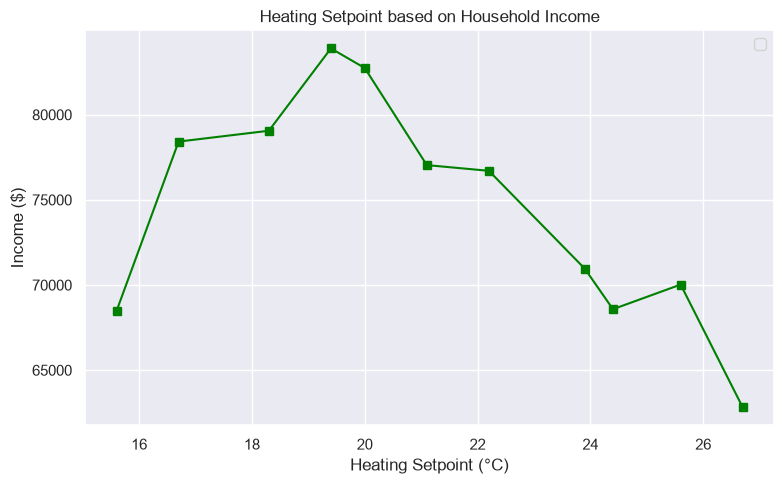

In [48]:
df_metadata_incomeheat = df_metadata.groupby('in.heating_setpoint')['in.income'].mean()
plt.figure(figsize=(8,5))
plt.plot(df_metadata_incomeheat.index, df_metadata_incomeheat.values, marker="s", color='green')
plt.title("Heating Setpoint based on Household Income")
plt.xlabel("Heating Setpoint (°C)")
plt.ylabel("Income ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\eassoumou1\AppData\Local\Temp\ipykernel_22084\211433449.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


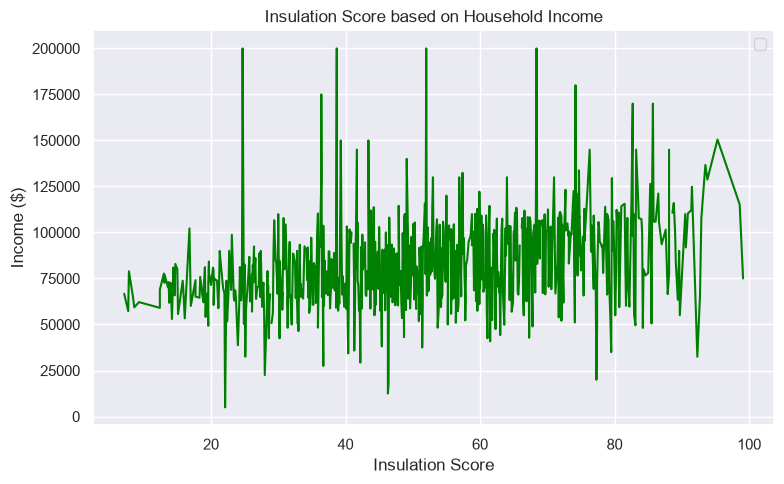

In [49]:
INSULATION = ['in.insulation_ceiling',
              'in.insulation_wall',
              'in.insulation_roof',
              'in.insulation_floor',
              'in.insulation_foundation_wall']

df_metadata_insulation = df_metadata.copy()
df_metadata_insulation[INSULATION] = df_metadata[INSULATION].apply(pd.to_numeric, errors='coerce')
df_metadata_insulation['in.insulation_score'] = df_metadata_insulation[INSULATION].sum(axis=1)
df_metadata_incomeinsulation = df_metadata_insulation.groupby('in.insulation_score')['in.income'].mean()

plt.figure(figsize=(8,5))
plt.plot(df_metadata_incomeinsulation.index, df_metadata_incomeinsulation.values, marker="", color='green')
plt.title("Insulation Score based on Household Income")
plt.xlabel("Insulation Score")
plt.ylabel("Income ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Visualisations par saisons

In [50]:
#Saisons d'après le fichier README
summer = [6,7,8,9]
winter = [1,2,3,12]
shoulder = [4,5,10,11]

summer_indices = [i-1 for i in summer]
winter_indices = [i-1 for i in winter]
shoulder_indices = [i-1 for i in shoulder]

keep_months=['out.total.energy_consumption','out.schedules.occupants','out.total.heating_consumption','out.total.cooling_consumption']

df_months = df_2.groupby('month')[keep_months].sum()
df_summer = df_months.iloc[summer_indices]
df_winter = df_months.iloc[winter_indices]
df_shoulder = df_months.iloc[shoulder_indices]


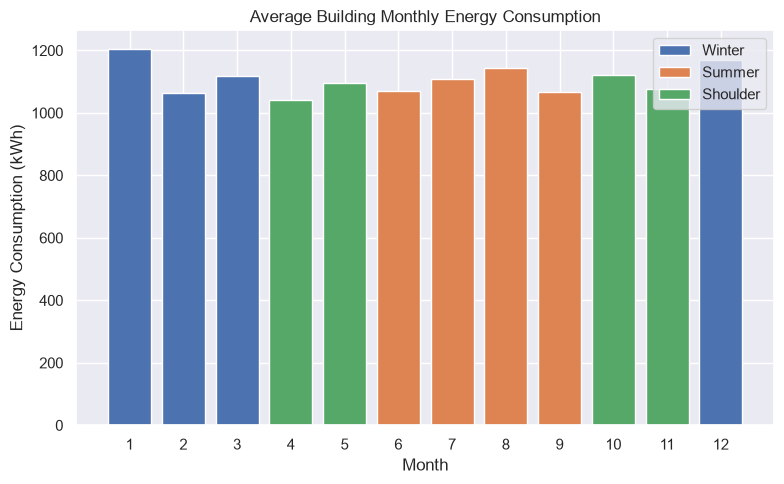

In [51]:
plt.figure(figsize=(8,5))

plt.bar(df_winter.index, df_winter['out.total.energy_consumption'], label='Winter')
plt.bar(df_summer.index, df_summer['out.total.energy_consumption'], label='Summer')
plt.bar(df_shoulder.index, df_shoulder['out.total.energy_consumption'], label='Shoulder')

plt.xticks(range(1,13))

plt.title("Average Building Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

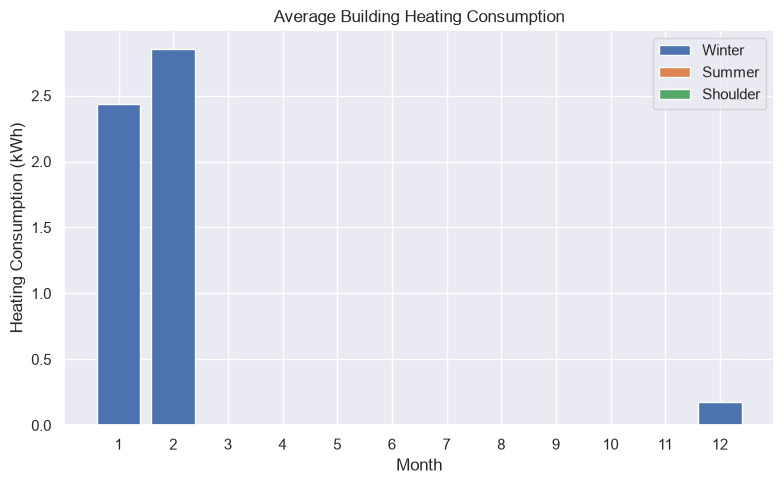

In [52]:
plt.figure(figsize=(8,5))

plt.bar(df_winter.index, df_winter['out.total.heating_consumption'], label='Winter')
plt.bar(df_summer.index, df_summer['out.total.heating_consumption'], label='Summer')
plt.bar(df_shoulder.index, df_shoulder['out.total.heating_consumption'], label='Shoulder')

plt.xticks(range(1,13))

plt.title("Average Building Heating Consumption")
plt.xlabel("Month")
plt.ylabel("Heating Consumption (kWh)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

        Valeurs bizzares en ordonnées

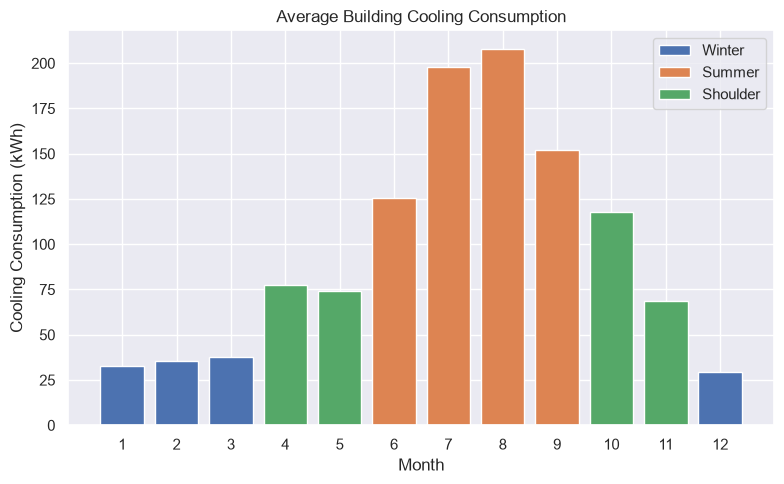

In [54]:
plt.figure(figsize=(8,5))

plt.bar(df_winter.index, df_winter['out.total.cooling_consumption'], label='Winter')
plt.bar(df_summer.index, df_summer['out.total.cooling_consumption'], label='Summer')
plt.bar(df_shoulder.index, df_shoulder['out.total.cooling_consumption'], label='Shoulder')

plt.xticks(range(1,13))

plt.title("Average Building Cooling Consumption")
plt.xlabel("Month")
plt.ylabel("Cooling Consumption (kWh)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

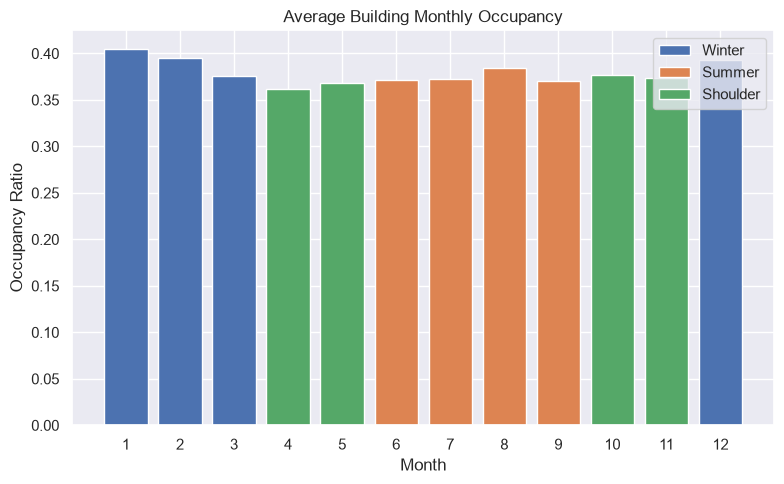

In [55]:
plt.figure(figsize=(8,5))
df_months = df_2.groupby('month')[keep_months].mean()
df_summer = df_months.iloc[summer_indices]
df_winter = df_months.iloc[winter_indices]
df_shoulder = df_months.iloc[shoulder_indices]

plt.bar(df_winter.index, df_winter['out.total.energy_consumption'], label='Winter')
plt.bar(df_summer.index, df_summer['out.total.energy_consumption'], label='Summer')
plt.bar(df_shoulder.index, df_shoulder['out.total.energy_consumption'], label='Shoulder')

plt.xticks(range(1,13))

plt.title("Average Building Monthly Occupancy")
plt.xlabel("Month")
plt.ylabel("Occupancy Ratio")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Visualisation du lien entre consommation et  équippements

In [56]:
for col in df.columns:
    print(col)

bldg_id
timestamp
in.sqft
out.electricity.ceiling_fan.energy_consumption..kwh
out.electricity.clothes_dryer.energy_consumption..kwh
out.electricity.clothes_washer.energy_consumption..kwh
out.electricity.cooling.energy_consumption..kwh
out.electricity.cooling_fans_pumps.energy_consumption..kwh
out.electricity.dishwasher.energy_consumption..kwh
out.electricity.ev_charging.energy_consumption..kwh
out.electricity.freezer.energy_consumption..kwh
out.electricity.heating.energy_consumption..kwh
out.electricity.heating_fans_pumps.energy_consumption..kwh
out.electricity.heating_hp_bkup.energy_consumption..kwh
out.electricity.heating_hp_bkup_fa.energy_consumption..kwh
out.electricity.hot_water.energy_consumption..kwh
out.electricity.hot_water_solar_th.energy_consumption..kwh
out.electricity.lighting_exterior.energy_consumption..kwh
out.electricity.lighting_garage.energy_consumption..kwh
out.electricity.lighting_interior.energy_consumption..kwh
out.electricity.mech_vent.energy_consumption..kwh
ou

In [57]:
"""out.electricity.range_oven.energy_consumption..kwh
out.electricity.refrigerator.energy_consumption..kwh
out.electricity.television.energy_consumption..kwh
out.electricity.permanent_spa_pump.energy_consumption..kwh
out.electricity.freezer.energy_consumption..kwh
out.electricity.dishwasher.energy_consumption..kwh
out.electricity.ceiling_fan.energy_consumption..kwh
out.electricity.clothes_dryer.energy_consumption..kwh
out.electricity.clothes_washer.energy_consumption..kwh"""

'out.electricity.range_oven.energy_consumption..kwh\nout.electricity.refrigerator.energy_consumption..kwh\nout.electricity.television.energy_consumption..kwh\nout.electricity.permanent_spa_pump.energy_consumption..kwh\nout.electricity.freezer.energy_consumption..kwh\nout.electricity.dishwasher.energy_consumption..kwh\nout.electricity.ceiling_fan.energy_consumption..kwh\nout.electricity.clothes_dryer.energy_consumption..kwh\nout.electricity.clothes_washer.energy_consumption..kwh'

In [58]:
APPLIANCES = [
'out.schedules.ceiling_fan',
'out.schedules.clothes_dryer',
'out.schedules.clothes_washer',
'out.schedules.cooking_range',
#'out.schedules.cooling_setpoint..c',
'out.schedules.dishwasher',
'out.schedules.hot_water_dishwasher',
'out.schedules.hot_water_fixtures',
#'out.schedules.lighting_garage',
'out.schedules.lighting_interior',
#'out.schedules.no_space_cooling',
#'out.schedules.no_space_heating',
'out.schedules.plug_loads_other',
'out.schedules.plug_loads_tv'
]
df_appliances = df_2.copy()
for col in df_appliances.columns :
    if col not in APPLIANCES and col != 'out.total.energy_consumption' and col != 'hour':
        df_appliances = df_appliances.drop(columns=col)

df_hourly_appliances = df_appliances.groupby('hour')[APPLIANCES].mean()

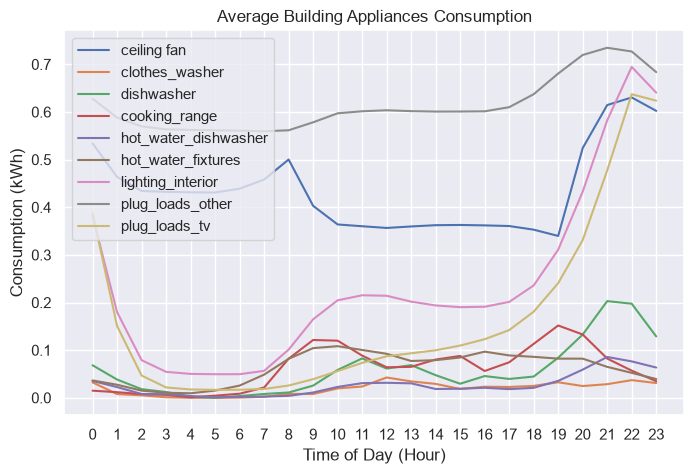

In [59]:
plt.figure(figsize=(8,5))

plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.ceiling_fan'], marker="", label='ceiling fan')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.clothes_dryer'], marker="", label='clothes_washer')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.dishwasher'], marker="", label='dishwasher')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.cooking_range'], marker="", label='cooking_range')
#plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.lighting_garage'], marker="", label='lighting_garage')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.hot_water_dishwasher'], marker="", label='hot_water_dishwasher')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.hot_water_fixtures'], marker="", label='hot_water_fixtures')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.lighting_interior'], marker="", label='lighting_interior')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.plug_loads_other'], marker="", label='plug_loads_other')
plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.plug_loads_tv'], marker="", label='plug_loads_tv')
#plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.no_space_cooling'], marker="", label='no_space_cooling')
#plt.plot(df_hourly_appliances.index, df_hourly_appliances['out.schedules.no_space_heating'], marker="", label='no_space_heating')

plt.title("Average Building Appliances Consumption")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Consumption (kWh)")
plt.xticks(range(24))
plt.grid(True)
plt.legend(loc='upper left')

#plt.tight_layout()
plt.show()

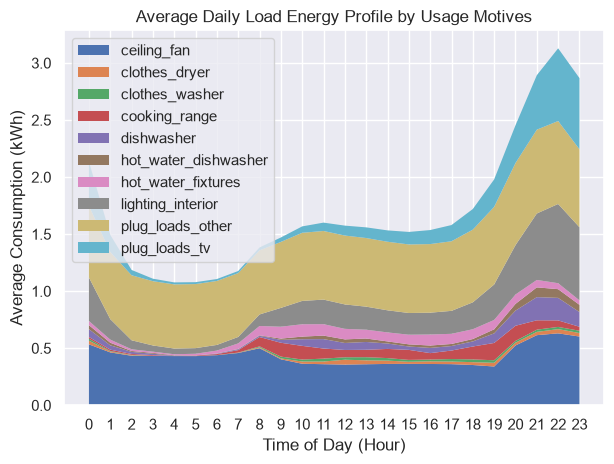

In [60]:
x = range(24)
names = [e[14:] for e in APPLIANCES]
group_totals = {appliance : df_appliances.groupby('hour')[appliance].mean().values for appliance in APPLIANCES}
y = [value for key, value in group_totals.items()]

#Tracé 
plt.title("Average Daily Load Energy Profile by Usage Motives")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average Consumption (kWh)")
plt.tight_layout()
plt.xticks(range(24))
plt.stackplot(x,y, labels=names, edgecolor="None")
plt.legend(loc='upper left')
plt.show()